This folder is sandboxed from the rest of the emulator, intended to test final emulator predictions using exact parameters.

In [1]:
saved_seds = []
saved_params = []

In [8]:
from tardis.io.atom_data import download_atom_data
download_atom_data('kurucz_cd23_cmfgen_H_He.h5')

ValueError: Atomic Data name kurucz_cd23_cmfgen_H_He.h5 not known

In [2]:
from emulator.interpolator import util as util
from emulator import config as em_config
from astropy.constants import sigma_T, m_p
import astropy.constants as const
import astropy.units as u

def make_abundances(X, Z):
    # Solar metallicity values 'vSZ16' from Vagnozzi (2019)
    metals = {
        'C': 0.003902,
        'N': 0.000951,
        'O': 0.007688,
        'Ne': 0.000905,
        'Mg': 0.001252,
        'Si': 0.001350,
        'S': 0.000847,
        'Fe': 0.002181,
        'Ca': 0.00010905
    }
    Y = 1 - X - Z
    s = sum(metals.values())
    for i in metals:
        metals[i] *= Z / s
    abundances = {'H': X, 'He': Y, **metals}
    return abundances

X = 0.7
Z = 0.002
abundances = make_abundances(X, Z)
data =  {'log_lsun': 8.64, 't_exp': 15.5, 'X': X, 'Z': Z, 'n': 7.63, 't_0': 10.0, 'abundances': abundances.copy()}
em_config.t_0 = data['t_0']

log_lsun = data['log_lsun']
t_exp = data['t_exp']
n = data['n']

v_phot = util.calc_v_phot(t_exp=t_exp, X=X, n=n)
v_outer = util.calc_v_outer(v_phot, n)
M, E = util.calc_model_mass(t_exp=t_exp, v_phot=v_phot, v_outer=v_outer, n=n)

print(v_phot)
print(M/const.M_sun)

6837.278483085944
0.019164434336943714


In [4]:
from tardis.io.configuration.config_reader import Configuration
from tardis.simulation import Simulation
from emulator.grid_run.make_csvy import make_csvy, make_abundances
from emulator.grid_run.run_tardis import set_threads
from emulator.interpolator import util as util
import astropy.constants as c
import astropy.units as u
import os

# Run simulation
set_threads(4)
sandbox_dir = os.path.abspath('.')
config_path = os.path.join(sandbox_dir, 'config.yml')
make_csvy(
    shells=10, # 40
    t_exp=t_exp,
    X=X,
    n=n,
    config_path=config_path,
    abundances=abundances
    # abundances=make_abundances(X, Z)
)
config = Configuration.from_yaml(config_path)
config.supernova.luminosity_requested = 10**log_lsun*c.L_sun
config.supernova.time_explosion = t_exp*u.day

from tardis.workflows.type_iip_workflow import TypeIIPWorkflow
sim = TypeIIPWorkflow(config, csvy=True)
sim.run()
# sim = Simulation.from_config(
#     config,
#     virtual_packet_logging=True,
#     show_convergence_plots=False,
#     export_convergence_plots=True,
#     log_level='DEBUG'
# )
# sim.run_convergence()
# sim.run_final()

# Save it
spectrum = sim.spectrum_solver.spectrum_integrated
saved_seds.append(spectrum.luminosity_density_lambda.value)
saved_params.append(data)

import subprocess
subprocess.run([
    'powershell.exe',
    '-c',
    '(New-Object Media.SoundPlayer "C:/Windows/Media/Alarm10.wav").PlaySync()'
])

BokehModel(combine_events=True, render_bundle={'docs_json': {'d8589ebe-fab2-4a05-9ed7-04504ba2a405': {'version…

First iteration use usual fb cooling rate


: 

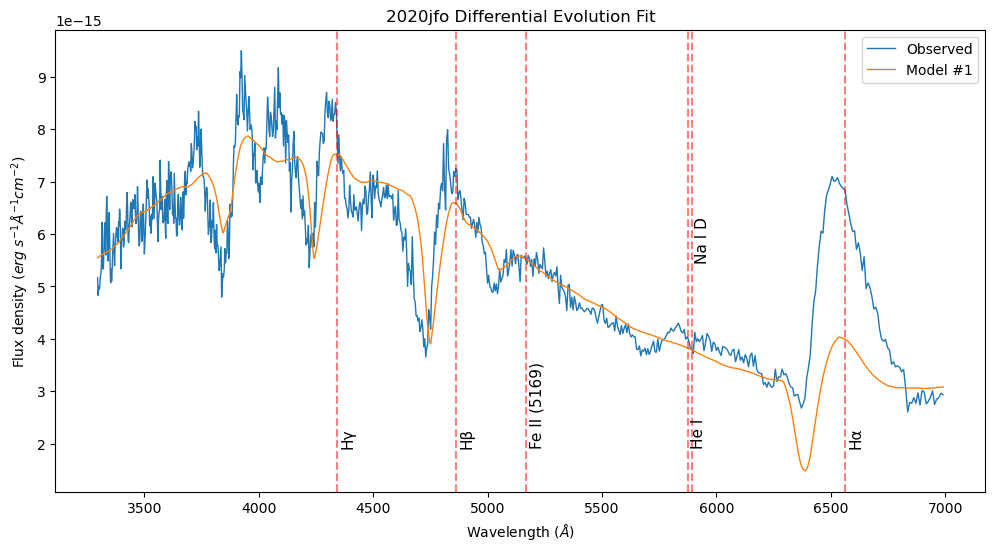

/tmp/ipykernel_1649/342667960.py:47: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



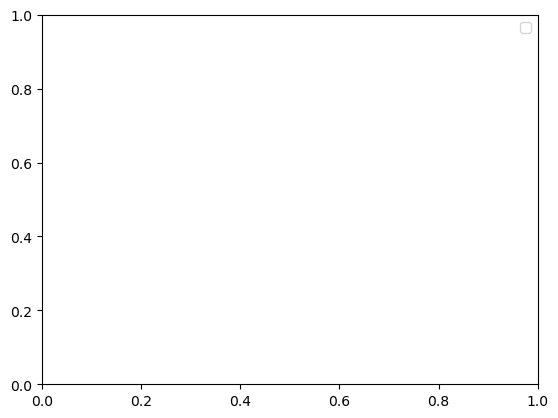

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

spectrum = sim.spectrum_solver.spectrum_integrated
y_mod = spectrum.luminosity_density_lambda.value
wav = spectrum.wavelength.value

# Get observed data
from scipy.interpolate import interp1d
obs_df = pd.read_csv(r'/home/mikel/GitHub/iip-emulator/emulator/interpolator/calibrated_spectra/2020jfo-2020-05-19.csv', comment='#')
y_obs = interp1d(obs_df['wavelength'], obs_df['flux'], bounds_error=False)(wav)
y_obs_err = interp1d(obs_df['wavelength'], obs_df['fluxerr'], bounds_error=False)(wav)

mask = ~np.isnan(y_obs)
mask = mask & (wav > 3000) & (wav < 7000)
wav = wav[mask]
y_obs = y_obs[mask]
y_mod = y_mod[mask]
y_obs_err = y_obs_err[mask]

# Setup continuum removal function
line_mask = ((wav > 6200) & (wav < 6900)) | ((wav > 4550) & (wav < 4900))
from numpy.polynomial import Polynomial
def continuum_removal(y_mod):
    c = Polynomial.fit(wav[~line_mask], y_obs[~line_mask]/y_mod[~line_mask], deg=3)
    p = c(wav)
    return p * y_mod

plt.figure(figsize=(12,6))
plt.plot(wav, y_obs, label='Observed', lw=1)

if False:
    plt.plot(wav, continuum_removal(y_mod), label='Model', lw=1)
    # plt.plot(wav, y_mod / y_mod.mean() * y_obs.mean(), label='Model', lw=1)
if True:
    for i, y_mod in enumerate(saved_seds):
        plt.plot(wav, continuum_removal(y_mod[mask]), lw=1, label='Model #' + str(i+1))

plt.title('2020jfo Differential Evolution Fit')
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel(r'Flux density ($erg~s^{-1}\AA^{-1}cm^{-2}$)')
plt.legend()
util.label_common_features()
plt.show()

plt.legend()
plt.show()

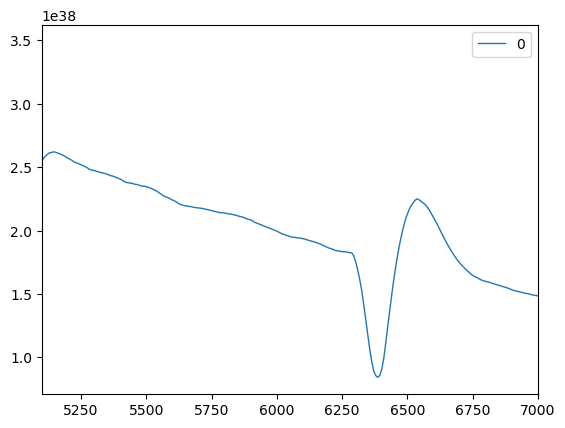

In [5]:
# Display all saved
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

wav = spectrum.wavelength.value

i = 0
for y_mod in saved_seds:
    plt.plot(wav, y_mod, lw=1, label=i)
    i += 1
plt.xlim(5100, 7000)
plt.legend()
plt.show()

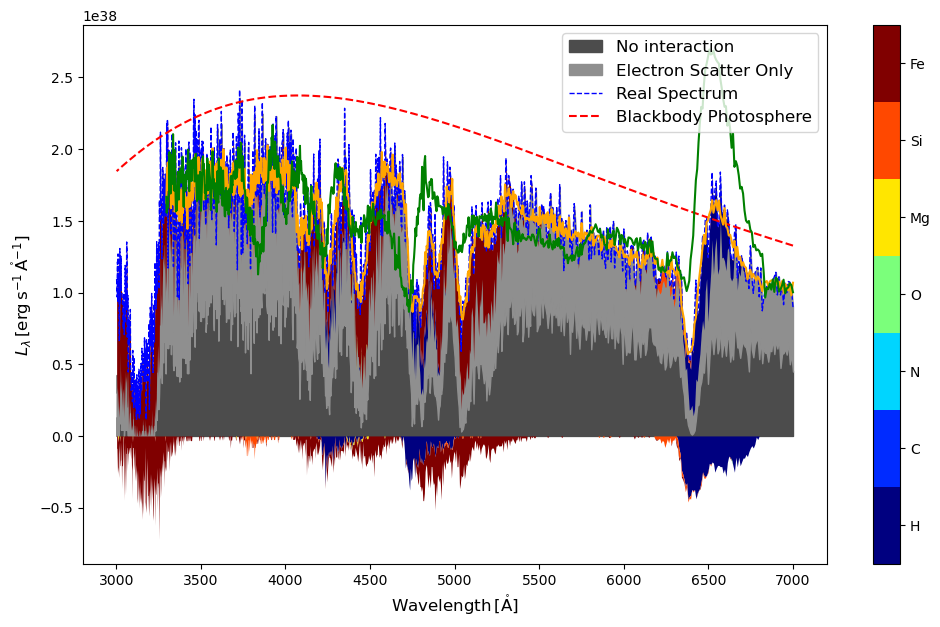

In [41]:
from tardis.visualization.tools.sdec_plot import SDECPlotter
plotter = SDECPlotter.from_simulation(sim)
plotter.generate_plot_mpl(packets_mode='real')

c = Polynomial.fit(wav[~line_mask], y_mod[~line_mask]/y_obs[~line_mask], deg=3)
p = c(wav)
y_obs_corr = p * y_obs
plt.plot(wav, y_mod, label='Model', c='orange')
plt.plot(wav, y_obs_corr, label='Observed', c='green')
plt.show()

In [7]:
import importlib

importlib.reload(util)

<module 'emulator.interpolator.util' from '/home/mikel/GitHub/iip-emulator/emulator/interpolator/util.py'>

In [ ]:
from emulator.grid_run.run_tardis import get_tau, get_phot
import emulator.interpolator.util as util

v, tau_thomson, tau_expansion, tau_planck, tau_rosseland = get_tau(sim, data['t_exp'])
v_phot, T_phot = get_phot(sim, v, tau_rosseland)
v_phot_pred = util.calc_v_phot(t_exp=data['t_exp'], X=data['X'], n=data['n'])
print(v_phot)
print(T_phot)
print(v_phot_pred)

7462.921902276372
10427.88098496157
7435.785962735473 km / s


In [ ]:
print(sim.plasma.plasma_properties_dict.keys())
print(sim.plasma.t_rad)

dict_keys(['DilutePlanckianRadField', 'NumberDensity', 'TimeExplosion', 'AtomicData', 'JBlues', 'LinkTRadTElectron', 'HeliumTreatment', 'ContinuumInteractionSpecies', 'NLTEIonizationSpecies', 'NLTEExcitationSpecies', 'TRadiative', 'DilutionFactor', 'BetaRadiation', 'Levels', 'Lines', 'PartitionFunction', 'GElectron', 'IonizationData', 'LinesLowerLevelIndex', 'LinesUpperLevelIndex', 'TauSobolev', 'StimulatedEmissionFactor', 'SelectedAtoms', 'ElectronTemperature', 'LevelBoltzmannFactorDiluteLTE', 'PhiSahaNebular', 'ZetaData', 'BetaElectron', 'RadiationFieldCorrection', 'LevelBoltzmannFactorNoNLTE', 'BetaSobolev', 'TransitionProbabilities', 'MacroAtomData', 'LevelNumberDensity', 'IonNumberDensity'])
[10456.29148217 10472.72051442 10488.85826101 10521.41993716
 10586.5300724  10650.94283362 10662.21639372 10727.91915526
 10737.53893447 10756.69193918 10812.34557325 10837.20567033
 10862.08068165 10844.16195828 10839.84979005 10840.00398966
 10750.27407959 10681.26759036 10595.30546481 1042

7609.0866464947985


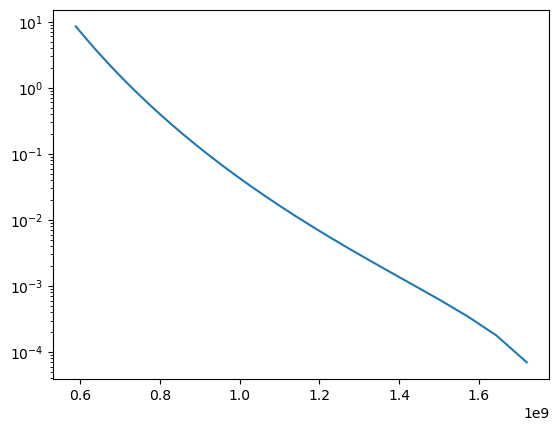

In [ ]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

# Compute Thomson optical depth
n_e = sim.plasma.electron_densities
sigma_T = c.sigma_T.cgs.value
kappa = n_e * sigma_T
v = ((sim.simulation_state.v_outer + sim.simulation_state.v_inner) / 2).cgs.value
dr = (sim.simulation_state.r_outer - sim.simulation_state.r_inner).cgs.value
tau = np.flip(np.cumsum(np.flip(kappa * dr)))
v_ph = (interp1d(tau, v)(2/3) *u.cm/u.s).to(u.km/u.s).value

print(v_ph)

plt.plot(v, tau)
plt.yscale('log')
plt.show()

7543.734526685361 km / s


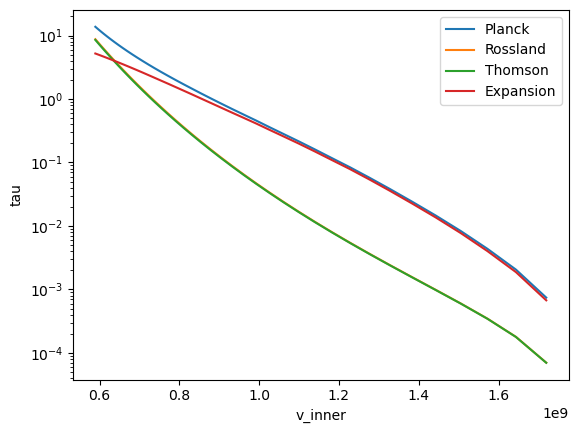

In [ ]:
from emulator.grid_run.run_tardis import get_tau, get_phot

v, tau_thomson, tau_expansion, tau_planck, tau_rosseland = get_tau(sim, t_exp.value, plot=True)
v_phot, T_phot = get_phot(sim, v, tau_rosseland)
print(v_phot, T_phot)

[ 5200.          5475.52943498  5826.97533949  6275.2549355
  6847.04875532  7576.38860323  8506.68304734  9693.30099399
 11206.86711303 13137.46524964 15600.        ]


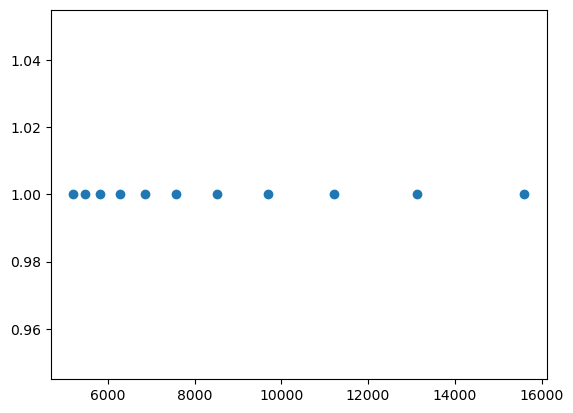

In [26]:
log_start = 3
start = 5200
stop = start * 3
shells = 10
v = (np.logspace(log_start, np.log10(stop-start+10**log_start), num=shells+1) + start - 10**log_start)
print(v)
plt.scatter(v, np.ones_like(v))
plt.show()

In [ ]:
for y_mod in saved_seds:
    y_mod = y_mod[mask]

    # Find best fit scale
    def f(x):
        scale = x[0]
        y1 = y_mod
        y2 = y_obs*scale
        fe = np.abs(y1 - y2)/y2
        mean_fe = np.mean(fe)
        mse = np.mean((y1-y2)**2)
        return mse

    from scipy.optimize import differential_evolution
    scale_guess = np.max(y_mod) / np.max(y_obs)
    result = differential_evolution(f, x0=[scale_guess], bounds=[(10**50, 10**60)])
    scale = result.x[0]
    distance = np.sqrt(scale/4/np.pi) * u.cm
    print('scale guess:', scale_guess)
    print('scale:', scale)
    print('distance:', distance.to(u.Mpc))

    plt.plot(wav, y_mod, label='model')
    plt.plot(wav, y_obs*scale, label='observed')
    plt.legend()
    plt.show()

In [ ]:
#print(sim.plasma.plasma_properties_dict.keys())
print(sim.plasma.dilute_planckian_radiation_field.temperature_kelvin)
print(sim.converged)
print(sim.iterations_executed)
print(sim.iterations_t_inner)